In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('../data/pipeline_incidents_clean.csv')
print(df.shape)
print(df['Significant'].value_counts())

(2024, 15)
Significant
0    1665
1     359
Name: count, dtype: int64


In [2]:
# Encode categorical columns into numbers
cat_cols = ['What happened category', 'Why it happened category',
            'Province', 'Substance', 'Release Type',
            'Pipeline or Facility Type', 'Emergency Level',
            'Population Density', 'Land Use', 'Company']

le = LabelEncoder()
df_encoded = df.copy()

for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

print(df_encoded.head(3))

   Significant  What happened category  Why it happened category  Province  \
0            0                      39                       103         0   
1            0                      39                       103         0   
2            0                      39                       103         0   

   Company  Substance  Release Type  Pipeline or Facility Type  \
0       14         21             3                          4   
1       14         21             3                          4   
2       14         21             3                          4   

   Approximate Volume Released (m3)  Year  Latitude  Longitude  \
0                               0.0  2012   53.5467 -113.35465   
1                               0.0  2012   53.5467 -113.35465   
2                               0.0  2012   53.5467 -113.35465   

   Emergency Level  Population Density  Land Use  
0                1                   5         8  
1                1                   5         8  
2   

In [3]:
# Split into features (X) and target (y)
X = df_encoded.drop('Significant', axis=1)
y = df_encoded['Significant']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")

Training rows: 1619
Testing rows: 405


In [4]:
# Train logistic regression baseline
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Make predictions
y_pred = lr_model.predict(X_test)

# See how it did
print("=== Logistic Regression Results ===")
print(f"Training accuracy: {lr_model.score(X_train, y_train):.3f}")
print(f"Testing accuracy: {lr_model.score(X_test, y_test):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=['Not Significant', 'Significant']))

=== Logistic Regression Results ===
Training accuracy: 0.844
Testing accuracy: 0.849

                 precision    recall  f1-score   support

Not Significant       0.85      0.99      0.92       344
    Significant       0.50      0.05      0.09        61

       accuracy                           0.85       405
      macro avg       0.68      0.52      0.50       405
   weighted avg       0.80      0.85      0.79       405



C:\Users\Abdul\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [5]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Results
print("=== Random Forest Results ===")
print(f"Training accuracy: {rf_model.score(X_train, y_train):.3f}")
print(f"Testing accuracy: {rf_model.score(X_test, y_test):.3f}")
print()
print(classification_report(y_test, y_pred_rf, target_names=['Not Significant', 'Significant']))

=== Random Forest Results ===
Training accuracy: 1.000
Testing accuracy: 0.896

                 precision    recall  f1-score   support

Not Significant       0.91      0.97      0.94       344
    Significant       0.74      0.48      0.58        61

       accuracy                           0.90       405
      macro avg       0.83      0.72      0.76       405
   weighted avg       0.89      0.90      0.89       405



In [7]:
from xgboost import XGBClassifier

# Calculate class weight ratio for imbalanced data
scale = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    scale_pos_weight=scale,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# Results
print("=== XGBoost Results ===")
print(f"Training accuracy: {xgb_model.score(X_train, y_train):.3f}")
print(f"Testing accuracy: {xgb_model.score(X_test, y_test):.3f}")
print()
print(classification_report(y_test, y_pred_xgb, target_names=['Not Significant', 'Significant']))

=== XGBoost Results ===
Training accuracy: 0.999
Testing accuracy: 0.899

                 precision    recall  f1-score   support

Not Significant       0.93      0.95      0.94       344
    Significant       0.68      0.62      0.65        61

       accuracy                           0.90       405
      macro avg       0.81      0.79      0.80       405
   weighted avg       0.90      0.90      0.90       405



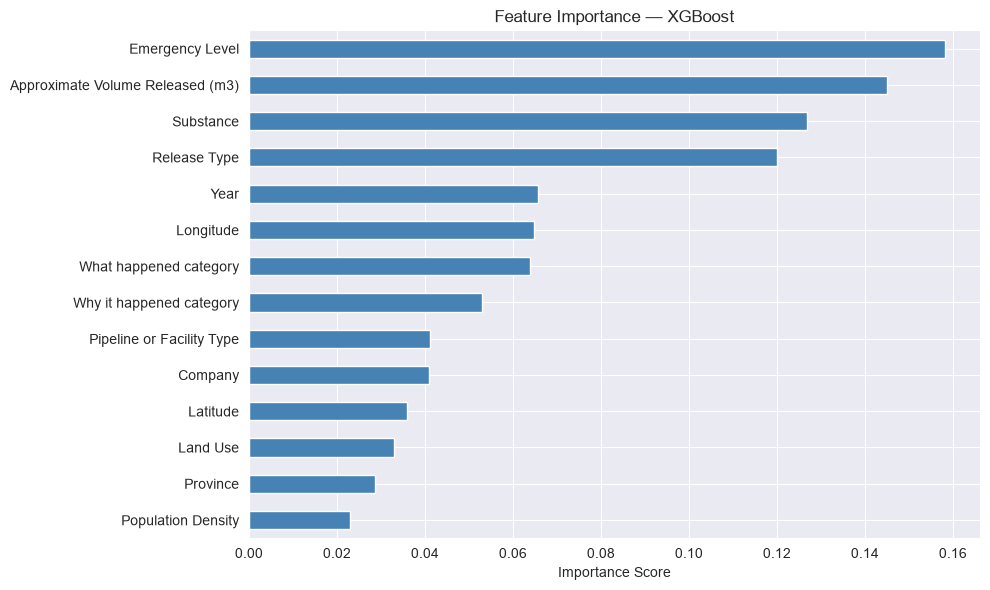

Emergency Level                     0.158243
Approximate Volume Released (m3)    0.145096
Substance                           0.126754
Release Type                        0.120002
Year                                0.065648
Longitude                           0.064895
What happened category              0.063850
Why it happened category            0.052954
Pipeline or Facility Type           0.041052
Company                             0.040915
Latitude                            0.035845
Land Use                            0.033011
Province                            0.028747
Population Density                  0.022988
dtype: float32


In [8]:
import matplotlib.pyplot as plt

# Get feature importance
importance = pd.Series(xgb_model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importance.plot(kind='barh', color='steelblue')
plt.title('Feature Importance — XGBoost')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../dashboard/feature_importance.png', dpi=150)
plt.show()

print(importance)